# TP2 - Informe tecnico

Sistema de Deteccion y Clasificacion de Razas de Perros — IA 5.2 Computer Vision.

## Equipo
- Alumno 1 : Martinez Dufour, Caterina.
- Alumno 2 : Tapia, Fabrizio.

### Librerías

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
import random
import kagglehub
import shutil
import os
from torchvision import transforms as transforms
import cv2
import time

from insightface.model_zoo import get_model
import json
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import gdown
import zipfile
import torch
import torchvision.models as models

## 1. Explicacion completa del pipeline

TO-DO: describir el flujo Embeddings -> Busqueda por similitud -> Clasificacion -> Deteccion -> Pipeline completo,
y como se integran los componentes (base vectorial, modelos, YOLO, aplicacion Gradio).

## 2. Dataset

TO-DO: distribucion de clases, cantidad de imagenes por raza, definicion de splits
(train/valid/test) y conjunto independiente de evaluacion.

In [3]:
# Descarga del dataset completo
dataset_path = kagglehub.dataset_download("gpiosenka/70-dog-breedsimage-data-set")
print(f"Los archivos se guardaron en la carpeta: {dataset_path}")

Los archivos se guardaron en la carpeta: C:\Users\Usuario\.cache\kagglehub\datasets\gpiosenka\70-dog-breedsimage-data-set\versions\2


Visualizamos algunas imágenes aleatorias para confirmar que la carga fue exitosa y verificar que los nombres de las carpetas correspondan a las identidades.

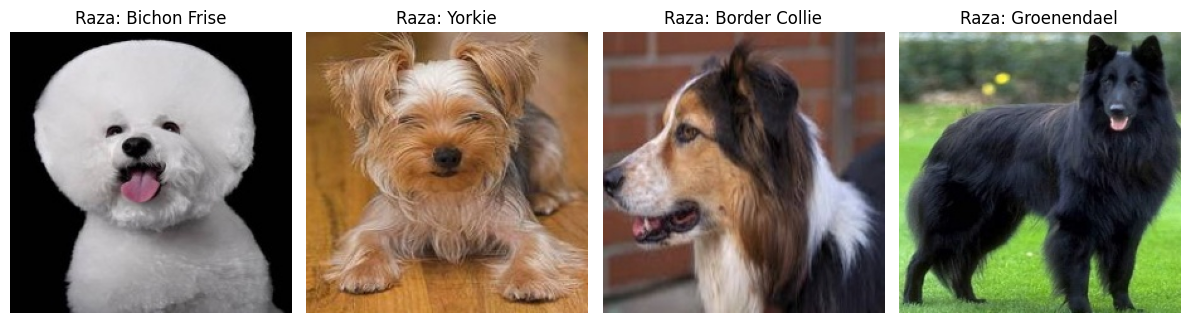

In [4]:
# Convertir la ruta de texto a objeto Path para poder usar .glob()
base_path = Path(dataset_path)
all_images = list(base_path.glob('**/*.jpg'))

# Visualizar las imágenes aleatorias
if all_images:
    sample_images = random.sample(all_images, min(4, len(all_images)))
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sample_images):
        plt.subplot(1, 4, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        # parent.name extrae el nombre de la carpeta
        plt.title(f"Raza: {img_path.parent.name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [5]:
# Contar imágenes por raza
identities = [p.parent.name for p in all_images]
counts = Counter(identities)
num_identities = len(counts)

print(f"\nAnálisis de razas:")
print(f"Total de razas únicas: {num_identities}")
print(f"Total de imágenes encontradas: {len(all_images)}")


Análisis de razas:
Total de razas únicas: 70
Total de imágenes encontradas: 9346


Podemos observar que hay una inconsistencia, observamos que hay un total de 71 razas y deberían ser 70 razas, por lo que analizaremos los nombres de cada raza para detectar si hay un error de carga:

In [6]:
print(sorted(list(counts.keys())))

['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise', 'Bichon Frise', 'Blenheim', 'Bloodhound', 'Bluetick', 'Border Collie', 'Borzoi', 'Boston Terrier', 'Boxer', 'Bull Mastiff', 'Bull Terrier', 'Bulldog', 'Cairn', 'Chihuahua', 'Chinese Crested', 'Chow', 'Clumber', 'Cockapoo', 'Cocker', 'Collie', 'Corgi', 'Coyote', 'Dalmation', 'Dhole', 'Dingo', 'Doberman', 'Elk Hound', 'French Bulldog', 'German Sheperd', 'Golden Retriever', 'Great Dane', 'Great Perenees', 'Greyhound', 'Groenendael', 'Irish Spaniel', 'Irish Wolfhound', 'Japanese Spaniel', 'Komondor', 'Labradoodle', 'Labrador', 'Lhasa', 'Malinois', 'Maltese', 'Mex Hairless', 'Newfoundland', 'Pekinese', 'Pit Bull', 'Pomeranian', 'Poodle', 'Pug', 'Rhodesian', 'Rottweiler', 'Saint Bernard', 'Schnauzer', 'Scotch Terrier', 'Shar_Pei', 'Shiba Inu', 'Shih-Tzu', 'Siberian Husky', 'Vizsla', 'Yorkie']


Podemos observar que la raza duplicada es 'American Spaniel', la cual fue escrita con un espacio de más. Para solucionar este problema, eliminaremos el espacio adicional unificando las carpetas en los 3 conjuntos dados (train, test y valid):

In [7]:
for split in ['train', 'test', 'valid']:
    split_dir = base_path / split
        
    # Definimos las rutas para ambas carpetas dentro del split actual
    carpeta_incorrecta = split_dir / "American  Spaniel"
    carpeta_correcta = split_dir / "American Spaniel"
    
    # Si la carpeta con el doble espacio existe, procedemos a unificarla
    if carpeta_incorrecta.exists():
        # Nos aseguramos de que la carpeta de destino correcta exista
        carpeta_correcta.mkdir(parents=True, exist_ok=True)
        # Movemos cada archivo .jpg a la ubicación corregida
        for archivo in carpeta_incorrecta.iterdir():
            shutil.move(str(archivo), str(carpeta_correcta / archivo.name))
            
        # Eliminamos la carpeta incorrecta
        carpeta_incorrecta.rmdir()

In [8]:
# Volvemos a escanear las imágenes para actualizar las rutas
all_images = list(base_path.glob('**/*.jpg'))

#### Análisis Estadístico de la distribución de las clases (global)

Para un sistema de reconocimiento de razas de perro, el balance del dataset es crítico. Analizaremos cuántas imágenes tenemos por perro y quiénes son las razas más frecuentes. Esto nos ayudará a decidir qué umbrales utilizar y cómo seleccionar nuestro conjunto de prueba.


Análisis de razas:
- Total de razas únicas: 70
- Promedio de fotos por raza: 134
- Raza con más fotos: Shih-Tzu (218 fotos)


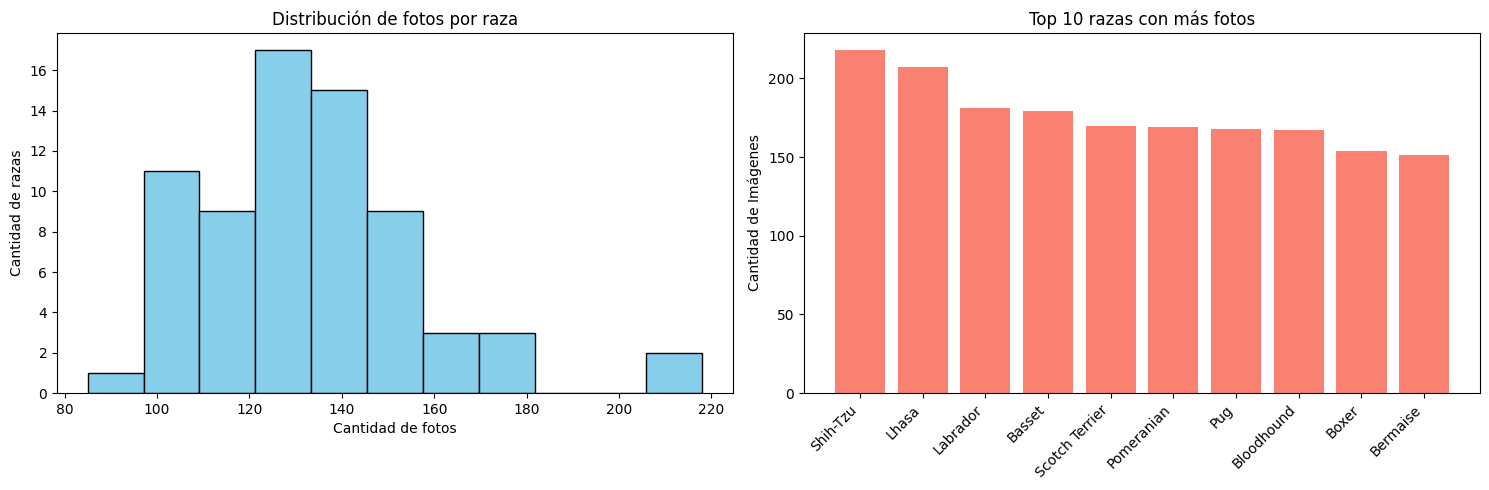

In [9]:
# Contar imágenes por raza (basado en el nombre de la carpeta padre)
identities = [p.parent.name for p in all_images]
counts = Counter(identities)

num_identities = len(counts)
img_per_breed = list(counts.values())

print(f"\nAnálisis de razas:")
print(f"- Total de razas únicas: {num_identities}")
print(f"- Promedio de fotos por raza: {len(all_images) / num_identities:.0f}")
print(f"- Raza con más fotos: {counts.most_common(1)[0][0]} ({counts.most_common(1)[0][1]} fotos)")

plt.figure(figsize=(15, 5))

# Visualización del histograma
plt.subplot(1, 2, 1)
plt.hist(img_per_breed, bins='auto', color='skyblue', edgecolor='black')
plt.title("Distribución de fotos por raza")
plt.xlabel("Cantidad de fotos")
plt.ylabel("Cantidad de razas")

# Visualización del Top 10
plt.subplot(1, 2, 2)
top_10 = counts.most_common(10)
plt.bar([x[0].replace('_', ' ') for x in top_10], [x[1] for x in top_10], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 razas con más fotos")
plt.ylabel("Cantidad de Imágenes")

plt.tight_layout()
plt.show()

Visualizamos que la gran cantidad de razas tienen un promedio de 132 fotos, siendo la raza Shih-Tzu la que tiene más con 218 fotos. También observamos que hay un bloque sin datos entre las barras (una brecha visual). Para evitar que el modelo tenga un sesgo (bias) hacia las clases con más muestras, decidimos aplicar una estrategia de balanceo del dataset bajo los siguientes criterios:
- Umbral mínimo: Se fijó un requerimiento de un piso mínimo de 100 imágenes por raza para asegurar que el modelo tenga suficiente información para extraer características consistentes.
- Umbral máximo (Submuestreo): Se limitó a un máximo de 150 imágenes por raza para mantener un dataset equilibrado.

In [10]:
# Agrupamos todas las imágenes por raza
razas_dict = {}
for p in all_images:
    nombre = p.parent.name
    if nombre not in razas_dict:
        razas_dict[nombre] = []
    razas_dict[nombre].append(p)

MIN_IMG = 100
MAX_IMG = 150
all_images_filtradas = []
nombres_seleccionados = []

for nombre, fotos in razas_dict.items():
    if len(fotos) >= MIN_IMG:
        # Truncamos el exceso de fotos por encima del máximo
        seleccionadas = fotos[:MAX_IMG]
        all_images_filtradas.extend(seleccionadas)
        nombres_seleccionados.append(nombre)

print(f"Razas que cumplen el criterio ({MIN_IMG}-{MAX_IMG} fotos): {len(nombres_seleccionados)}")
print(f"Total de imágenes para procesar: {len(all_images_filtradas)}")

Razas que cumplen el criterio (100-150 fotos): 63
Total de imágenes para procesar: 8406


Como podemos observar en el resultado, las razas que superaban las 150 imágenes fueron recortadas, pero aquellas que se encuentran entre las 100 y 149 fotos conservan su cantidad original momentáneamente en esta estructura para la Etapa 1.

Por lo tanto, para que los tamaños no queden mezclados y garantizar un dataset perfectamente equilibrado y libre de sesgos, utilizaremos técnicas de Data Augmentation y remuestreo en la Etapa 2. De esta forma, expandiremos artificialmente las muestras de las clases minoritarias hasta que todas las razas presenten exactamente 150 imágenes.

#### Conjunto independiente para evaluación

Con el objetivo de evaluar la capacidad real de generalización de nuestro buscador por similitud (Etapa 1) y calcular la métrica NDCG@10, construimos un conjunto de evaluación independiente al dataset original de Kaggle. Para esto, recolectamos manualmente de internet un total de 140 imágenes (exactamente 2 imagenes por cada una de las 70 razas analizadas). El criterio de selección se basó en buscar imágenes que presenten desafíos visuales ausentes en el conjunto de entrenamiento, tales como variaciones en el fondo, diferentes ángulos de los perros y cambios de iluminación. 

Este dataset se estructuró en un directorio llamado conjunto_independiente_val, manteniendo las mismas etiquetas de las clases pero sin unificarlo físicamente con los splits originales. Para descargar el dataset lo realizamos a través del enlace de Google Drive: "https://drive.google.com/file/d/1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h/view". Descargamos desde el Drive el dataset de los perros en formato zip, lo descomprimimos y lo almacenamos:

In [11]:
# Definimos las rutas
base_path = Path(".")
dataset_original_path = Path(r"C:\Users\Usuario\.cache\kagglehub\datasets\gpiosenka\70-dog-breedsimage-data-set\versions\2")
eval_path = base_path / "data" / "conjunto_independiente_val"

# ID del archivo ZIP en Google Drive
file_id = '1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = base_path / "data" / 'dataset_perros.zip'

(base_path / "data").mkdir(parents=True, exist_ok=True)

# Descarga el archivo si no existe
if not eval_path.exists():
    gdown.download(url, str(archivo_descargado), quiet=False)
    # Extraemos el contenido
    try:
        print("Descomprimiendo archivos...")
        with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
            zip_ref.extractall(base_path / "data")
            
        # Eliminar el archivo .zip temporal descargado
        if archivo_descargado.exists():
            os.remove(archivo_descargado)
        
    except zipfile.BadZipFile:
        print("Error")

## 3. Preprocesamiento

TO-DO: tecnicas aplicadas (resize, normalizacion, data augmentation, filtrado) y su justificacion.

### Preprocesamiento necesario para la Etapa 1

En este preprocesamiento estaremos realizando una redimensión de las imágenes a 224x224 píxeles, debido a que este es el tamaño de entrada estricto con el que fue diseñada y entrenada originalmente la arquitectura ResNet. Para poder pasar las nuevas imágenes por el modelo, primero las convertimos a un tensor, lo cual escala automáticamente los valores de los píxeles de un rango de 0-255 a un rango de 0 a 1. Finalmente, normalizamos utilizando la media y la desviación estándar oficiales de ImageNet, es por eso que pusimos esos valores específicos en el código, garantizando así que cualquier imagen externa se procese bajo la misma distribución estadística de iluminación y color con la que el modelo base fue pre-entrenado.

In [12]:
transform_etapa1 = transforms.Compose([
    transforms.ToPILImage(), # Agregamos esto solo para que acepte el array de OpenCV
    # Redimensionar la imagen en 224 x 224
    transforms.Resize((224, 224)),                         
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),                                 
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

A diferencia del Resize y la Normalización, este filtro lo aplicamos de manera previa a la conversión de tensores mediante una rutina de validación con la librería PIL. Establecemos un umbral mínimo de resolución de 64x64 píxeles. Decidimos descartar aquellas imágenes que no cumplan con esta dimensión debido a que, al realizar el escalado forzado a 224x224, el proceso de interpolación genera un efecto de pixelado extremo (ruido geométrico). Esto distorsionaría las características visuales que extrae la ResNet50, degradando la precisión del buscador por similitud.

In [13]:
def calidad_img(path_imagen, min_dim):
    """
    Verifica si una imagen cumple con los estándares mínimos de calidad.
    """
    with Image.open(path_imagen) as img:
        ancho, alto = img.size
        if ancho < min_dim or alto < min_dim:
            return False # Descartada por resolución demasiado baja            
    return True # La imagen pasa el filtro de calidad

In [14]:
all_images_calidad = []

for p in all_images_filtradas:
    if calidad_img(p, min_dim=64):
        all_images_calidad.append(p)

imagenes_descartadas = len(all_images_filtradas) - len(all_images_calidad)
print(f"Total de imágenes descartadas por baja calidad: {imagenes_descartadas}")

Total de imágenes descartadas por baja calidad: 0


### Preprocesamiento necesario para la Etapa 2

●  Data Augmentation.

●  Horizontal Flip. 

●  Rotación. 

●  Blur. 

●  Variaciones de brillo.

●  Variaciones de contraste.

●  Ruido

## 4. Justificacion de los modelos elegidos

TO-DO: modelo de embeddings baseline (Etapa 1), ResNet18 fine-tuned y CNN custom (Etapa 2),
YOLO (Etapa 3). Analizar trade-offs: precision, velocidad de inferencia, consumo de memoria
y complejidad computacional.

### modelo de embeddings baseline (Etapa 1)

En esta sección se desarrolla la función principal de predicción, integrando todas las etapas del sistema en un flujo continuo (End-to-End). La función recibe una imagen sin procesar y ejecuta el pipeline completo:

- extract_embedding(image): Código para pasar una imagen por el modelo pre-entrenado en ImageNet (ResNet50) y extraer su vector de características.  
- search_similar_images(embedding, top_k=10): Código para buscar los 10 vectores más cercanos (Top-10) en la base de datos vectorial (usando ChromaDB, FAISS o pgvector) mediante Cosine Similarity o Distancia Euclidiana (L2).  
- predict_breed_from_neighbors(results): Código para predecir la raza del perro basándote en las etiquetas de las imágenes más similares encontradas (los vecinos más cercanos).

Especificaciones de la Interfaz (Gradio):
- Input: Imagen de un perro.
- Output: Imagen consultada, visualización en cuadrícula del Top 10 de imágenes similares recuperadas de la base de datos, y la Raza predicha final.

In [15]:
def load_image(source_path: str) -> np.ndarray:
    image = cv2.imread(str(source_path))
    if image is None:
        raise ValueError(f"Could not read image: {source_path}") # BGR uint8 (convencion OpenCV)
    return image

#### Extraer embeddings de imágenes

Para extraer los embeddings decidimos utilizar el modelo pre-entrenado de ResNet-50, debido a que devuelve un vector de 2048 dimensiones por cada imagen. A diferencia de EfficientNet-B0 (que genera 1280 dimensiones), esto nos da un espacio geométrico más amplio para almacenar detalles morfológicos y estructuras globales de los perros. Además, presenta un consumo de memoria bajo y una velocidad de inferencia sumamente rápida en entornos de GPU.

In [16]:
def extract_embedding(image: np.ndarray) -> list[float]:
    """
    Genera el embedding de una imagen usando un modelo pre-entrenado en
    ImageNet (ResNet50) sin la capa de clasificacion final.

    Sugerencias:
        - Preprocesar la imagen (resize a self.image_size, normalizacion ImageNet).
        - Usar torchvision.models o timm con pesos pre-entrenados.
        - Recordar que la imagen llega en BGR (OpenCV).
    Retorna una lista de floats de dimension EMBEDDING_DIM.
    """
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)                # Convertimos de BGR a RGB 
    tensor_image = transform_etapa1(image_rgb)                        # Aplicamos las transformaciones
    tensor_image = tensor_image.unsqueeze(0)                          # agrega una dimensión extra de tamaño 1 en la posición 0
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)  # Cargamos el modelo ResNet-50
    model.fc = torch.nn.Identity()                                    # Reemplazamos la última capa lineal de clasificación (.fc) por Identity
    
    model.eval()

    # Extracción de la lista de Floats
    with torch.no_grad():
        output = model(tensor_image)                                  # Pasamos el tensor por la red neuronal
        embedding_np = output.squeeze().cpu().numpy()                 # Del tensor se elimina las dimensiones extra de tamaño 1 y lo convierte a un array
        embedding_list = embedding_np.tolist()                        # Convertimos el array a una lista de Python

    return embedding_list

####  Construir una base de datos vectorial

A continuación, construimos una base de datos vectorial local en formato JSON para almacenar los embeddings indexados. La información se organiza en una estructura de diccionario donde cada clave (ruta de la imagen) contiene los atributos breed (raza) y embedding (vector de características). Este archivo servirá como nuestro Feature Store para utilizar de forma eficiente la función search_similar_images.

In [ ]:
ARCHIVO_JSON = "json_embeddings.json"
galeria_dict = {}

print("Generando base de datos JSON...")
for path in tqdm(all_images_calidad, desc="Indexando"):
    try:
        path_str = str(path)                                # Convertimos el path a un string plano de Python
        breed = os.path.basename(os.path.dirname(path_str)) # Extraemos la raza de la carpeta
        img = load_image(path_str)                          # Cargamos la imagen
        emb = extract_embedding(img)                        # extraemos sus características
        
        # Guardamos la estructura usando el string como clave
        galeria_dict[path_str] = {"breed": breed, "embedding": emb}

    except Exception as e:
        continue

# Guardamos el diccionario como un archivo JSON
with open(ARCHIVO_JSON, 'w') as f:
    json.dump(galeria_dict, f, indent=4)

Generando base de datos JSON...


Indexando: 100%|██████████| 8406/8406 [58:34<00:00,  2.39it/s] 


#### Recuperar imágenes similares (search_similar_images)

Para implementar la recuperación de imágenes similares, utilizamos el archivo json_embeddings generado previamente en conjunto con las funciones provistas por la cátedra: cosine (similitud del coseno), l2_similarity (distancia euclidiana normalizada) y similarity (función unificada que actúa como selector de métrica). La evaluación cuantitativa para determinar cuál de las dos métricas ofrece un mejor rendimiento en el modelo final se detallará en la sección "6. Resultados obtenidos, Etapa 1: NDCG@10 y justificación del resultado".

In [17]:
def cosine(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def l2_similarity(a: np.ndarray, b: np.ndarray) -> float:
    dist = float(np.linalg.norm(a - b))
    return 1.0 / (1.0 + dist)

def similarity(query: list[float], ref: list[float], similarity_metric: str = "cosine") -> float:
    a = np.asarray(query, dtype=np.float32)
    b = np.asarray(ref, dtype=np.float32)
    if similarity_metric.lower() == "l2":
        return l2_similarity(a, b)
    return cosine(a, b)

Esta función se encarga de recuperar desde nuestro almacenamiento local en JSON el Top - K de las imágenes más similares al embedding de consulta. El algoritmo itera sobre todos los elementos indexados, calcula el score de similitud delegando la operación en la función similarity (aplicando Coseno o L2 de manera dinámica según el parámetro seleccionado) y finalmente ordena el conjunto de forma descendente para retornar los K vecinos más cercanos.

In [18]:
def search_similar_images(embedding: list[float], top_k: int, metric: str) -> list[dict]:
    """
    Recupera de la base vectorial las top_k imagenes mas similares.
    Busca de forma local en el archivo JSON e itera los elementos usando similarity().
    """
    with open("json_embeddings.json", "r") as f:                    # Lee el archivo JSON
        db = json.load(f)
        
    raw_results = []

    for path, data in db.items():                                   # Recorremos el diccionario del JSON
        breed = data["breed"]
        stored_embedding = data["embedding"]
        
        # Usamos la función con la metrica elegida (coseno o L2)
        score = similarity(embedding, stored_embedding, similarity_metric=metric)
        
        # Guardamos en un diccionario nativo
        raw_results.append({
            "path": path,
            "breed": breed,
            "score": score
        })
        
    # Gracias a la normalización L2 (1 / 1 + dist), ambas métricas a mayor valor, tienen mayor similitud
    # Ordenamos de forma descendente para asegurar que el Top-K contenga los mejores resultados
    raw_results.sort(key=lambda x: x["score"], reverse=True)
    
    return raw_results[:top_k]

#### Clasificar razas utilizando búsqueda por similitud

Para resolver la predicción final de la raza a partir de los K resultados recuperados del JSON, implementamos una variante del algoritmo k-NN con voto ponderado por similitud. El flujo de clasificación consta de:
-  Umbral de Similitud: Dado que el ranking de vecinos se encuentra ordenado de forma decreciente, evaluamos el primer elemento (el más similar). Si este score es inferior a un umbral crítico de 0.5, el sistema determina que la imagen como "unknown" (desconocido). 
-  Votación Ponderada: Utilizamos el score de similitud de cada vecino como el peso de su voto. De este modo, los perros recuperados del JSON con un nivel de confianza muy alto tienen un impacto significativamente mayor en la decisión final.

Tras iterar los resultados y acumular los pesos en un diccionario de frecuencias, se extrae la raza que haya recolectado el mayor puntaje consolidado. Finalmente, la función retorna una tupla compuesta por la raza ganadora y el score de confianza individual del mejor vecino.

In [19]:
def predict_breed_from_neighbors(results: list[dict]) -> tuple[str, float]:
    """
    Predice la raza a partir de los vecinos recuperados usando k-NN ponderado por score.
    Si el mejor score del primer vecino es menor a similarity_threshold, devuelve "unknown".
    """
    # Si la búsqueda no trajo nada, se clasifica como 'desconocido'
    if not results:
        return "unknown", 0.0
        
    # Como la lista ya viene ordenada de mayor a menor, el primer elemento es el que tiene el score más alto.
    mejor_score = results[0]["score"]
    if mejor_score < 0.5:
        return "unknown", 0.0

    # Aplica k-NN con Voto Ponderado
    votos_por_raza = {}
    
    for vecino in results:
        raza = vecino["breed"]
        score = vecino["score"]
        
        # Sumamos el score como el "peso" del voto para esa raza
        if raza in votos_por_raza:
            votos_por_raza[raza] += score
        else:
            votos_por_raza[raza] = score
            
    # Obtiene la raza más votada
    raza_ganadora = max(votos_por_raza, key=votos_por_raza.get)
    
    return raza_ganadora, mejor_score

#### Pipeline completo

In [20]:
def pipeline_prediccion(image, top, metrica) -> tuple[str, float, list[dict]]:
    """
    Pipeline principal End-to-End. Integra Carga, Extracción, Búsqueda y Clasificación k-NN.
    
    Input: Imagen de un perro.
    Output: Imagen consultada del Top k de imágenes similares recuperadas de la base de datos, y la Raza predicha final.
    """
    # Carga la imagen
    if isinstance(image, str):
        img = load_image(image)
    else:
        img = image 
        
    # Extracción de embedding
    embedding = extract_embedding(img)
    
    # Búsqueda de imágenes similares
    vecinos = search_similar_images(embedding, top_k=top, metric=metrica)
    
    # Clasificación de raza 
    raza_final, confianza = predict_breed_from_neighbors(vecinos)
    
    return raza_final, confianza, vecinos

### ResNet18 fine-tuned y CNN custom (Etapa 2)

Completar

### YOLO (Etapa 3)

Completar

## 5. Proceso de entrenamiento e hiperparametros

TO-DO: proceso de fine-tuning, hiperparametros utilizados (learning rate, batch size, epochs,
optimizador, scheduler), curvas de entrenamiento.

## 6. Resultados obtenidos

TO-DO:
- Etapa 1: NDCG@10 y justificacion del resultado.
- Etapa 2: accuracy, precision, recall, specificity, F1, matriz de confusion.

### Etapa 1: NDCG@10 y justificacion del resultado.

Para evaluar el rendimiento de nuestro buscador por similitud de manera cuantitativa y objetiva, utilizamos el conjunto independiente de evaluación que construimos previamente (las 140 imágenes descargadas de internet, correspondientes a 2 fotos por cada una de las 70 razas).

In [21]:
ruta_val = Path(r"C:\Users\Usuario\tuia-dog-recognition-app\data\conjunto_independiente_val")

all_images_ind_val = []
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG'):
    all_images_ind_val.extend(list(ruta_val.rglob(ext)))

# Filtramos los duplicados
all_images_ind_val = list(set(all_images_ind_val))

print(f"Conjunto de evaluación independiente cargado")
print(f"Cantidad de imágenes encontradas: {len(all_images_ind_val)}")

Conjunto de evaluación independiente cargado
Cantidad de imágenes encontradas: 140


Por cada una de estas imágenes externas, el sistema ejecuta la predicción completa y recupera las 10 muestras indexadas más cercanas en la base de datos vectorial. A partir de este orden de llegada, calculamos la métrica NDCG@10, asignando una relevancia binaria (1 si el resultado coincide con la raza de la consulta, y 0 si pertenece a otra). Esta métrica es ideal porque premia al algoritmo si las imágenes correctas aparecen en los primeros puestos del ranking y penaliza fuertemente si se desplazan hacia el final del Top-10. El cálculo de la métrica se resume en tres pasos:
1. DCG (Puntaje Real): Se recorre el Top-10 asignando relevancia binaria (1 si acierta la raza, 0 si no). Cada acierto se divide por el logaritmo de su posición ($\log_2(\text{posición} + 1)$), premiando los aciertos en los primeros puestos y penalizándolos fuertemente si caen al final de la lista.
2. IDCG (Puntaje Ideal): Es el valor máximo teórico que obtendría un buscador perfecto, calculando el escenario utópico donde los 10 resultados son aciertos consecutivos (diez valores de relevancia 1).
3. NDCG (Normalización): Se divide el puntaje real sobre el ideal mediante la fórmula$$NDCG = \frac{DCG}{IDCG}$$El resultado es un índice estandarizado acotado entre 0 y 1, donde 1 representa un ordenamiento perfecto.

In [ ]:
def calcular_ndcg_at_10(vecinos: list[dict], raza_real: str) -> float:
    """
    Calcula el NDCG@10 para una única consulta. 
    Asigna relevancia 1 si coincide la raza, 0 si no.
    """
    dcg = 0.0
    
    # Calculamos el DCG observado en base al ranking real que devolvió el buscador
    for i, vecino in enumerate(vecinos):
        # Pasamos ambos strings a minúsculas para que coincidan
        raza_vecino_limpia = vecino["breed"].lower()
        raza_real_limpia = raza_real.lower()
        
        # Relevancia binaria
        rel = 1.0 if raza_vecino_limpia == raza_real_limpia else 0.0
        posicion = i + 1
        dcg += rel / np.log2(posicion + 1)
        
    # Calculamos el IDCG Real
    idcg = 0.0
    for i in range(10):
        posicion = i + 1
        idcg += 1.0 / np.log2(posicion + 1)
        
    if idcg == 0.0:
        return 0.0
        
    return dcg / idcg

In [24]:
tiempo_inicio = time.time()
scores_ndcg_cosine = []

for path_test in tqdm(all_images_ind_val, desc="Evaluando con Coseno"):
    # Extraemos la raza real de la ruta de la imagen externa
    raza_real = os.path.basename(os.path.dirname(str(path_test)))
        
    # Procesamos la imagen de consulta
    img = load_image(str(path_test))
        
    # Utilizamos el pipeline con un top-10 y la metrica de 'similitud del coseno'
    raza_pred, conf, vecinos_recuperados = pipeline_prediccion(img, top=10, metrica="cosine")
    
    # Evaluamos la función con NCDG@10
    ndcg_foto = calcular_ndcg_at_10(vecinos_recuperados, raza_real)
    scores_ndcg_cosine.append(ndcg_foto)

tiempo_fin = time.time()

# 3. Calculamos la diferencia y el tiempo promedio por imagen
tiempo_total_segundos = tiempo_fin - tiempo_inicio
tiempo_promedio_por_imagen = tiempo_total_segundos / len(all_images_ind_val)

# Calculamos el promedio final de la métrica
ndcg_promedio_cosine = sum(scores_ndcg_cosine) / len(scores_ndcg_cosine)

print(f"NDCG@10 Promedio Final (Cosine): {ndcg_promedio_cosine:.4f}")
print(f"Tiempo total de ejecución (seg): {tiempo_total_segundos:.2f}")
print(f"Tiempo promedio de ejecución por imagen (seg): {tiempo_promedio_por_imagen:.4f}")

Evaluando con Coseno: 100%|██████████| 140/140 [17:11<00:00,  7.37s/it]

NDCG@10 Promedio Final (Cosine): 0.5160
Tiempo total de ejecución (seg): 1031.61
Tiempo promedio de ejecución por imagen (seg): 7.3686


In [25]:
tiempo_inicio = time.time()
scores_ndcg_l2 = []

for path_test in tqdm(all_images_ind_val, desc="Evaluando con L2"):
    # Extraemos la raza real de la ruta de la imagen externa
    raza_real = os.path.basename(os.path.dirname(str(path_test)))
        
    # Procesamos la imagen de consulta
    img = load_image(str(path_test))
        
    # Utilizamos el pipeline con un top-10 y la metrica de 'distancia euclidiana'
    raza_pred, conf, vecinos_recuperados = pipeline_prediccion(img, top=10, metrica="l2")
    
    # Evaluamos la función con NCDG@10
    ndcg_foto = calcular_ndcg_at_10(vecinos_recuperados, raza_real)
    scores_ndcg_l2.append(ndcg_foto)

tiempo_fin = time.time()

# 3. Calculamos la diferencia y el tiempo promedio por imagen
tiempo_total_segundos = tiempo_fin - tiempo_inicio
tiempo_promedio_por_imagen = tiempo_total_segundos / len(all_images_ind_val)

# Calculamos el promedio final de la métrica
ndcg_promedio_l2 = sum(scores_ndcg_l2) / len(scores_ndcg_l2)

print(f"NDCG@10 Promedio Final (L2): {ndcg_promedio_l2:.4f}")
print(f"Tiempo total de ejecución L2 (seg): {tiempo_total_segundos:.2f}")
print(f"Tiempo promedio de ejecución por imagen L2 (seg): {tiempo_promedio_por_imagen:.4f}")

Evaluando con L2: 100%|██████████| 140/140 [17:00<00:00,  7.29s/it]

NDCG@10 Promedio Final (L2): 0.5190
Tiempo total de ejecución L2 (seg): 1020.99
Tiempo promedio de ejecución por imagen L2 (seg): 7.2928


Tras evaluar el conjunto independiente de validación bajo ambas configuraciones (similitud del coseno y distancia euclidiana), se comparo la calidad del ranking (NDCG@10) y la eficiencia computacional (Tiempo de ejecución). Como se observa en los resultados, la métrica de Distancia Euclidiana (L2) demostró una ligera superioridad en ambos aspectos. Alcanzó un NDCG@10 promedio de 0.5190, superando sutilmente al 0.5160 obtenido por la Similitud Coseno y presentó una reducción en los tiempos de cómputo, con un promedio de 7.29 segundos por imagen (frente a los 7.36 segundos de Coseno).

Si bien las diferencias son marginales en ambas métricas, la consistencia de la Distancia Euclidiana (L2) como la opción más rápida y precisa determina su selección como la configuración definitiva para el pipeline de producción en la interfaz de usuario.

### Etapa 2: accuracy, precision, recall, specificity, F1, matriz de confusion.

## 7. Comparacion entre enfoques

TO-DO: busqueda por similitud vs clasificacion supervisada; ResNet18 fine-tuned vs CNN custom.

## 8. Problemas encontrados y soluciones implementadas

TO-DO.

## 9. Modificaciones fuera de las funciones indicadas

TO-DO: justificar debidamente cualquier cambio realizado fuera de las funciones
indicadas en cada etapa (si no hubo, indicarlo).